### <span style="text-decoration: double underline; color:rgb(17, 129, 221)">**Resultados Finales Classic** </span>

#### <span style="text-decoration: underline; color:rgb(17,129,221)">**1. Métricas durante el Train** </span>

Estas métricas son con respecto a la matriz de confusión, por lo que no están focalizadas a que estructuralmente coincidan.

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = ""
import Auxiliares.Funciones.Results.func_evaluacion_init as evaluator_init
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import Auxiliares.Funciones.Boards.func_load_npz as loader
import Auxiliares.Funciones.Graficas.func_graficador as grapher
import Auxiliares.Funciones.Modelo.func_conway as conway
import Auxiliares.Clases.class_GoLayer as GoLayer

In [9]:
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621, 8421, 15678,  19302, 38475, 77293, 91827, 99100]
shape = (15,15)
path_datos =  './Resultados/Resultados_Classic'
path_datos = Path(path_datos)
path_historiales = []
path_test_results = []
path_predicciones = {}
path_reales = {}
for seed in seeds:
    path_historial= path_datos/f'Train/Historiales/history_{seed}.csv'
    path_test_result= path_datos/f'Test/Metricas/test_results_{seed}.csv'
    path_prediccion = path_datos/f'Test/Predicciones/predicciones_{seed}.csv'
    path_real = path_datos/f'Boards/Test/test_{seed}.npz'
    path_historiales.append(path_historial)
    path_test_results.append(path_test_result)
    path_predicciones[f'{seed}'] = path_prediccion
    path_reales[f'{seed}'] = path_real

Loss en train: 0.0754 ± 0.0001
Loss en val: 0.0770 ± 0.0004



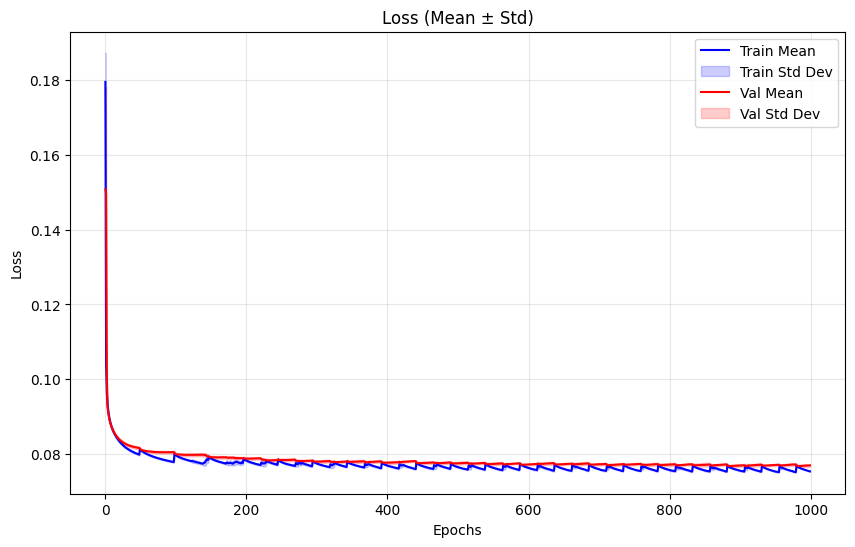

Accuracy en train (init): 0.8722 ± 0.0002
Accuracy en val (init): 0.8693 ± 0.0007

Recall en train (init): 0.6137 ± 0.0007
Recall en val (init): 0.6064 ± 0.0040

Precision en train (init): 0.7376 ± 0.0005
Precision en val (init): 0.7294 ± 0.0022

Specificity en train (init): 0.9415 ± 0.0002
Specificity en val (init): 0.9397 ± 0.0010

F1score en train (init): 0.6700 ± 0.0005
F1score en val (init): 0.6622 ± 0.0018

absolute en train (init): 0.0049 ± 0.0004
absolute en val (init): 0.0049 ± 0.0009



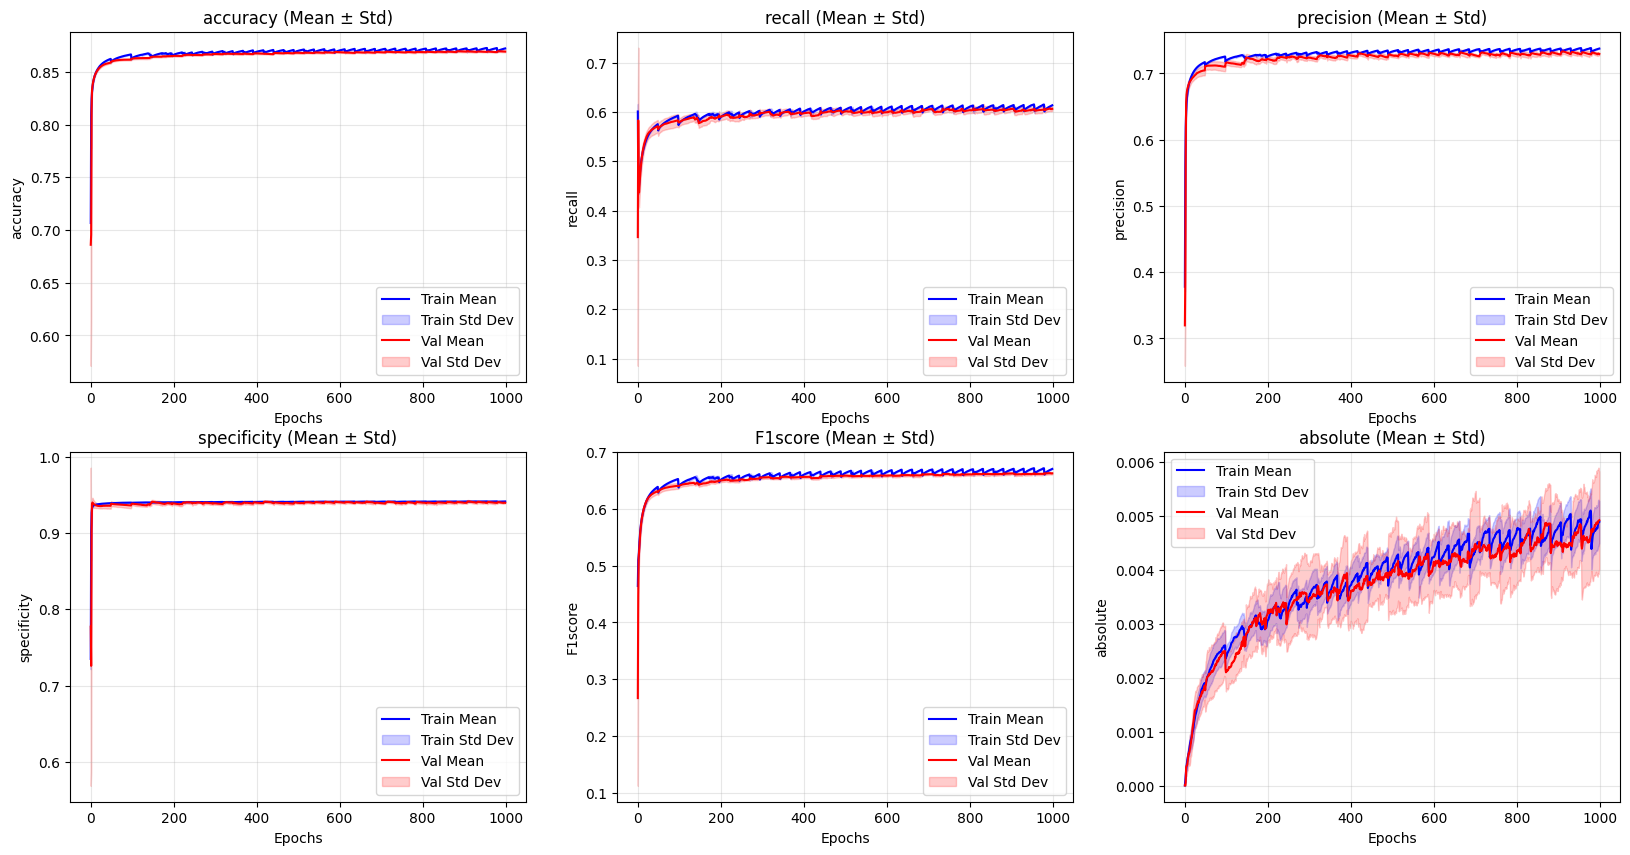

In [3]:
evaluator_init.loss_train_val(path_historiales)
evaluator_init.metrics_train_val(path_historiales,'init')

#### <span style="text-decoration: underline; color:rgb(17,129,221)">**2. Métricas en Test** </span>

In [4]:
headers = pd.read_csv(path_test_results[0]).columns.tolist()
evaluator_init.metrics_test(path_test_results, headers, headers)

F1score (iniciales): 0.6525 ± 0.0029
absolute (iniciales): 0.0038 ± 0.0006
accuracy (iniciales): 0.8584 ± 0.0005
loss (iniciales): 0.0820 ± 0.0002
precision (iniciales): 0.7244 ± 0.0030
recall (iniciales): 0.5936 ± 0.0063
specificity (iniciales): 0.9348 ± 0.0016


#### <span style="text-decoration: underline; color:rgb(17,129,221)">**3. Plot de tableros** </span>

##### <span style="text-decoration: underline wavy; color:rgb(17,129,221)">**3.1. Comparativa** </span>

In [4]:
#  Headers de los csv:
stop_cols = [f"stop_{i}" for i in range(shape[0]*shape[1])]
init_cols = [f'start_{i}' for i in range(shape[0]*shape[1])]

# Datos para los plots:
umbral = 0.5
seed2plot = 1204

file_pred = path_predicciones[f'{seed2plot}']
file_test = path_datos/f'Boards/Test/test_{seed2plot}.npz'

    # Lectura de tableros predichos:
df_predicciones = pd.read_csv(file_pred, sep=',')

    # Preparación de tableros predichos:
# Tableros iniciales predichos:
init_prob = df_predicciones[init_cols].values  # (15_000, shape[0], shape[1])
init_bin = init_prob >umbral

# Tableros finales predichos:
finales_prob = df_predicciones[init_cols].values # (15_000, shape[0], shape[1])
finales_bin = finales_prob > umbral

# Tableros reales:

_ ,tab_iniciales, tab_finales = loader.load_npz(file_test, f'test_{seed2plot}.npz')

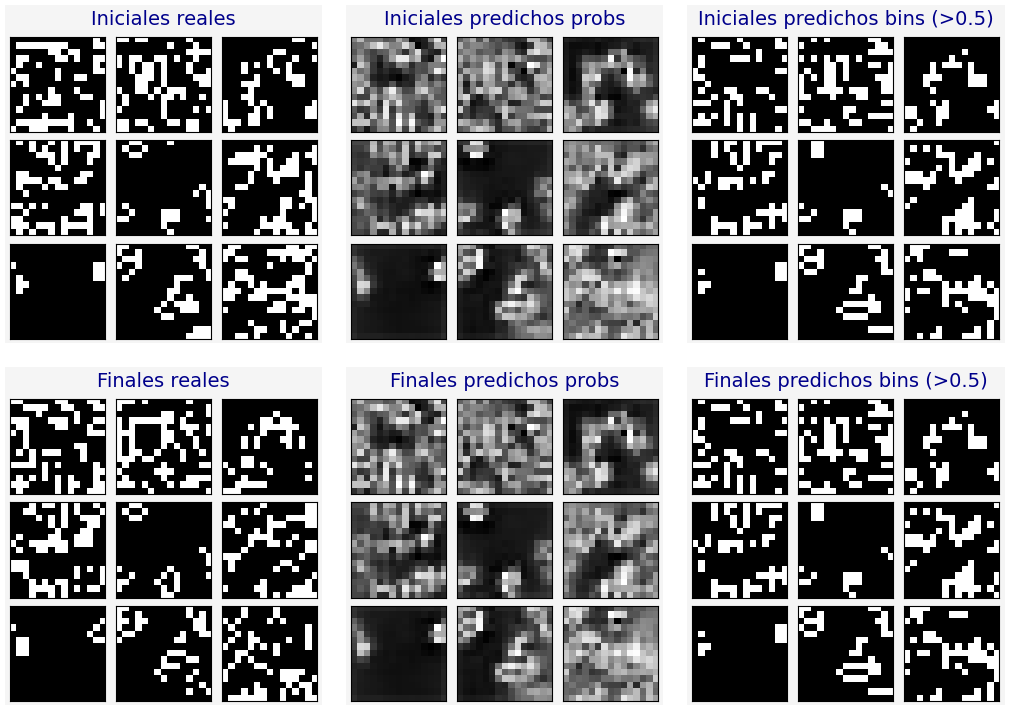

In [6]:
rows, cols = 3,3  # Número de tableros para ver
figsize = (10,7) # Ajustar el tamaño de la figura para que se vea bien.
random = False # Por si quereis ver tableros aleatorios (True o False)
tabs2plot = [tab_iniciales, init_prob, init_bin, tab_finales, finales_prob, finales_bin]
titles = ['Iniciales reales', 'Iniciales predichos probs', f'Iniciales predichos bins (>{umbral})', 
          'Finales reales', 'Finales predichos probs', f'Finales predichos bins (>{umbral})']

evaluator_init.multiplots(tabs2plot, titles, rows, cols, figsize, random)

##### <span style="text-decoration: underline wavy; color:rgb(17,129,221)">**3.2. Evolución** </span>

2026-02-20 09:06:06.715550: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


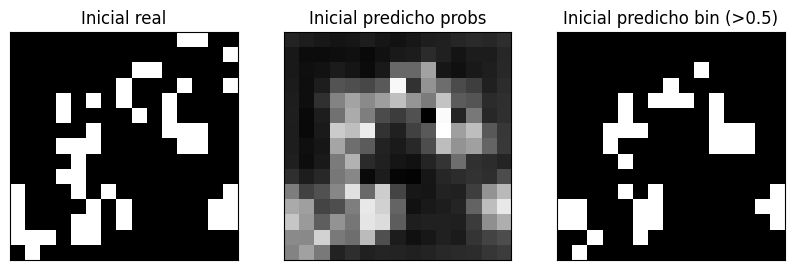

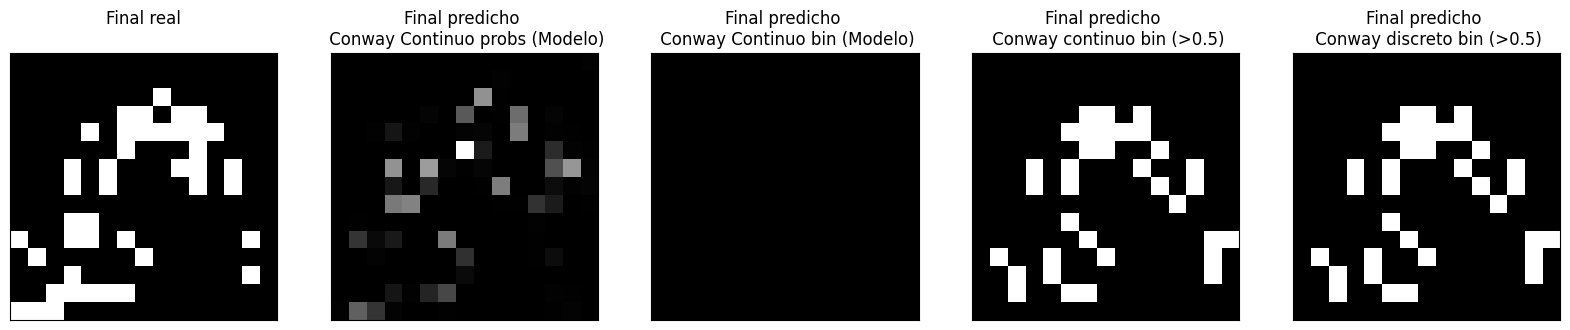

In [7]:
indice2plot = 2
# indice2plot = np.random.randint(0, len(tab_iniciales), 1) 

evaluator_init.evolution(indice2plot, init_bin, init_prob, tab_iniciales, tab_finales, umbral, (10,8), 'init')
evaluator_init.evolution(indice2plot, init_bin, init_prob, tab_iniciales, tab_finales, umbral, (20,10), 'final')

#### <span style="text-decoration: underline; color:rgb(17,129,221)">**4. Densidades** </span>

Densidad media predicha: 32.25%
Densidad media real: 22.36%
Desviación estándar pred: 8.36%
Desviación estándar real: 9.37%
Error en la densidad: 9.89%
Error en la std: 1.02%
Error medio por tablero: 13.33%
Células totales: 50625000
%HUC: 35.46% ± 0.31%
Porcentaje de células dudosas: 35.46% (17949363 células)
Valor máximo en las predicciones: 0.9846746


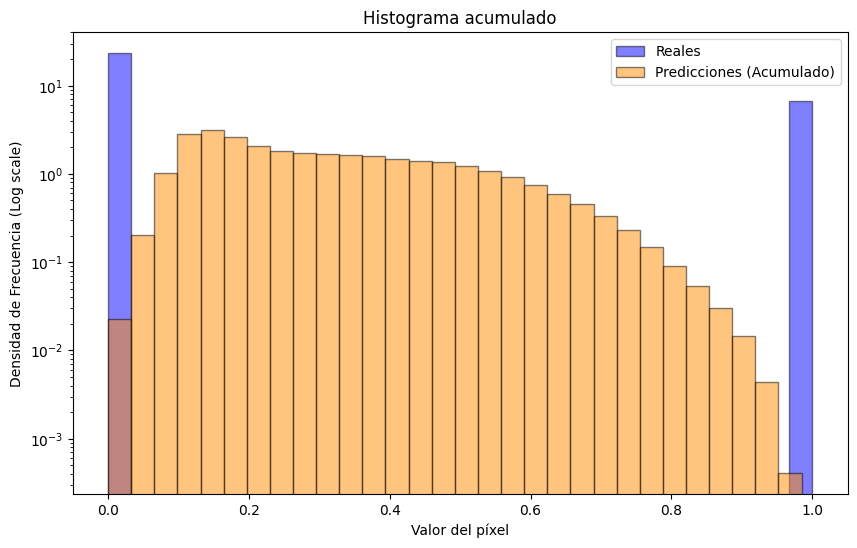

In [12]:
evaluator_init.density(path_predicciones, tab_iniciales, init_cols)
fig = evaluator_init.histograma(path_predicciones, tab_iniciales, init_cols, 0.35, 0.65)

#### <span style="text-decoration: underline; color:rgb(17,129,221)">**5. Wasserstein, Fuzziness Index, MSE y Sobolev sobre Iniciales** </span>

In [9]:
evaluator_init.compute_Wasserstein(path_predicciones, path_reales, init_cols)
evaluator_init.fuzzines_index(path_predicciones, init_cols)
evaluator_init.Sobolev(path_reales, path_predicciones, init_cols, shape, umbral, normalize=True)
evaluator_init.MSE(path_predicciones, path_reales, init_cols, umbral)

Wasserstein (EMD): 2.0252 ± 0.0227
Fuzziness Index: 0.7495 ± 0.0062
Sobolev medio modelo(prob): 2.7523 ± 0.0260 
Sobolev medio modelo(bin): 2.4946 ± 0.0102
Sobolev medio baseline OX: 3.0126
Sobolev medio baseline OY: 3.0119
Sobolev medio all zeros: 4.7037
Sobolev medio all ones: 12.0981
Sobolev medio si inversión: 10.7317
Sobolev medio si fuzzy boards: 5.3658
Diferencia Media en OX (bin): 0.5179
Diferencia Media en OY (bin): 0.5173
Diferencia Media en OX (prob): 0.2602
Diferencia Media en OY (prob): 0.2596
MSE Medio  (prob): 0.1220 ± 0.0007
MSE Medio (bin): 0.1416 ± 0.0005
MSE Medio allzeros: 0.2239 ± 0.0004


#### <span style="text-decoration: underline; color:rgb(17,129,221)">**6. Wasserstein, Fuzziness Index, MSE, Sobolev sobre Finales** </span>

In [10]:
import Auxiliares.Funciones.Results.func_evaluacion_fin as evaluator_fin

evaluator_fin.MSE(path_predicciones, path_reales, init_cols, umbral, classic=True)
evaluator_fin.fuzziness_index(path_predicciones, init_cols, classic=True)
evaluator_fin.compute_Wasserstein(path_predicciones, path_reales, init_cols, classic=True)
evaluator_fin.Sobolev(path_reales, path_predicciones, init_cols, shape, umbral, normalize=True, classic=True)

MSE Medio  (prob): 0.2079 ± 0.0012
MSE Medio (bin): 0.2199 ± 0.0005
MSE Medio allzeros: 0.2200 ± 0.0004
Fuzziness Index: 0.0696 ± 0.0010
Wasserstein (EMD): 2.9835 ± 0.0328
Sobolev medio modelo(prob): 4.3542 ± 0.0148 
Sobolev medio modelo(bin): 4.6393 ± 0.0063
Sobolev medio baseline OX: 2.9775
Sobolev medio baseline OY: 2.9781
Sobolev medio all zeros: 4.6483
Sobolev medio all ones: 12.1537
Sobolev medio si inversión: 10.8378
Sobolev medio si fuzzy boards: 5.4189
Diferencia Media en OX (bin): 1.6617
Diferencia Media en OY (bin): 1.6612
Diferencia Media en OX (prob): 1.3766
Diferencia Media en OY (prob): 1.3761


#### <span style="text-decoration: underline; color:rgb(17,129,221)">**7. Equivalencia diffGoL y GoL** </span>

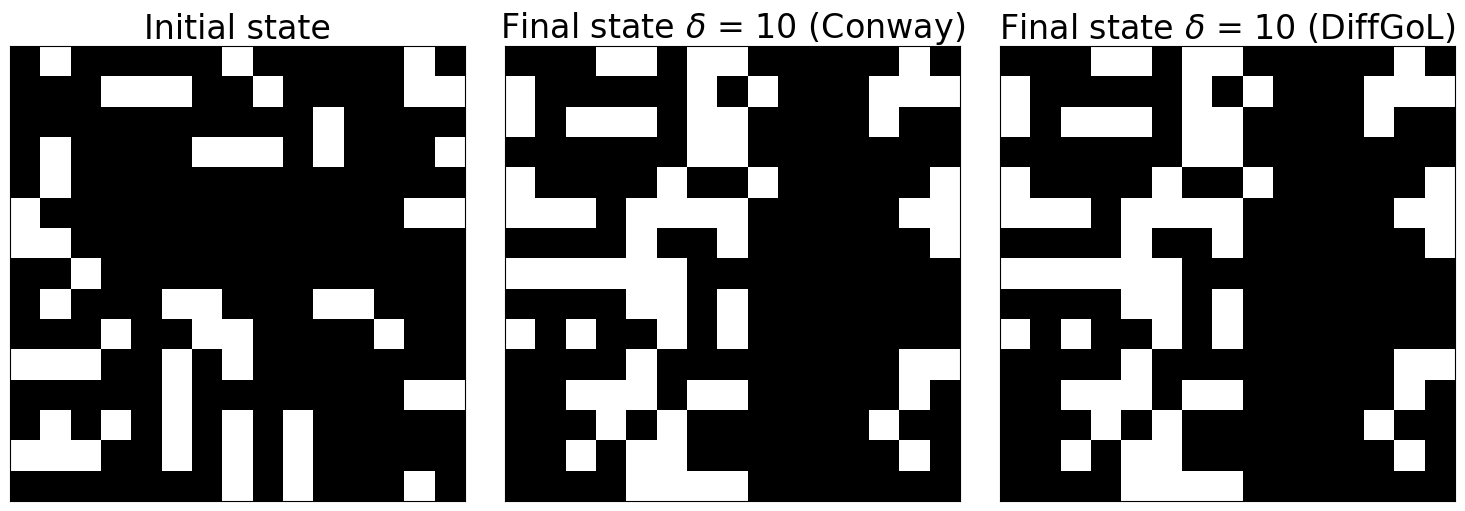

In [11]:
indice2plot = 0
inicial_bin = init_bin[indice2plot].reshape(15,15)

final_x_Conway = conway.game_of_life(inicial_bin, delta=10)
capa =  GoLayer.ConwayLayer(delta=10, epsilon=50, order=4)
final_x_diffGoL = capa(inicial_bin.reshape(1,15,15,1)).numpy().reshape(15,15) 
fig, axs = plt.subplots(1, 3, figsize=(15,5))
titles = ['Initial state', r'Final state $\delta$ = 10 (Conway)', r'Final state $\delta$ = 10 (DiffGoL)']
boards = [inicial_bin, final_x_Conway, final_x_diffGoL]
for ax, title, board in zip(axs, titles, boards):
    ax.set_title(title, fontsize=24)   
    ax.imshow(board, cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()